In [9]:
import json
from pathlib import Path

import polars as pl


class JsonDatasetLoader:
    def __init__(self, folder: str | Path = "."):
        self.folder = Path(folder)

    def get_files(self) -> list[Path]:
        return sorted(
            path
            for path in self.folder.iterdir()
            if path.is_file() and path.suffix.lower() == ".json"
        )

    def read_file(self, path: Path) -> dict:
        with path.open("r", encoding="utf-8") as file:
            return json.load(file)


    def load_records(self) -> pl.DataFrame:
        dataframes = []

        for path in self.get_files():
            data = self.read_file(path)
            records = data.get("records", [])

            if not isinstance(records, list):
                raise ValueError(f"Key 'records' pada {path.name} harus berupa list")

            if not records:
                continue

            dataframe = pl.from_dicts(
                records,
                strict=False,
                infer_schema_length=None,
            )

            dataframe = (
                dataframe.rename(
                    {
                        "title": "title_url",
                    }
                )
                .with_columns(
                    pl.col("content").struct.field("title").alias("title_content"),
                    pl.col("content").struct.field("text").alias("text"),
                    pl.col("content").struct.field("status").alias("content_status"),
                    pl.lit(path.name).alias("source_file"),
                )
                .drop("content")
                .select(
                    "source_file",
                    "title_url",
                    "title_content",
                    "text",
                    "content_status",
                    pl.exclude(
                        "source_file",
                        "title_url",
                        "title_content",
                        "text",
                        "content_status",
                    ),
                )
            )

            dataframes.append(dataframe)

        if not dataframes:
            return pl.DataFrame()

        return pl.concat(
            dataframes,
            how="diagonal_relaxed",
        )

    def load_meta(self) -> pl.DataFrame:
        rows = []

        for path in self.get_files():
            data = self.read_file(path)
            meta = data.get("meta", {})

            rows.append(
                {
                    **meta,
                    "source_file": path.name,
                }
            )

        if not rows:
            return pl.DataFrame()

        return pl.from_dicts(rows, strict=False).select(
            "source_file",
            pl.exclude("source_file"),
        )

    def get_columns(self) -> list[str]:
        return self.load_records().columns

In [10]:
loader = JsonDatasetLoader(folder="./datasets/url_discovery")
loader.get_files()

meta_df = loader.load_meta()
display(meta_df)
print(loader.get_columns())

source_file,built_at,search_label,source_files,record_count,content_count,query_count
str,str,str,struct[3],i64,i64,i64
"""dataset_20260627T094855Z.json""","""2026-06-27T09:48:55.240893+00:…","""SHS/PLTS Kalimantan Barat""","{""E:\Work\personal\url-discovery\data\urls.json"",""E:\Work\personal\url-discovery\data\contents.json"",""E:\Work\personal\url-discovery\data\search_state.json""}",214,214,335
"""dataset_20260627T101253Z.json""","""2026-06-27T10:12:53.267116+00:…","""SHS/PLTS Kalimantan Barat""","{""E:\Work\personal\url-discovery\data\urls.json"",""E:\Work\personal\url-discovery\data\contents.json"",""E:\Work\personal\url-discovery\data\search_state.json""}",203,203,268
"""dataset_20260627T135259Z.json""","""2026-06-27T13:52:59.725144+00:…","""SHS/PLTS Kalimantan Barat""","{""E:\Work\personal\url-discovery\data\urls.json"",""E:\Work\personal\url-discovery\data\contents.json"",""E:\Work\personal\url-discovery\data\search_state.json""}",88,88,197


['source_file', 'title_url', 'title_content', 'text', 'content_status', 'canonical_url', 'url', 'domain', 'snippet', 'published_date_hint', 'first_found_at', 'last_found_at', 'found_by', 'is_blacklisted']


In [11]:
COLUMN_SELECTED = [
    pl.col("canonical_url"),
    pl.col("domain"),
    pl.col("title_url"),
    pl.col("title_content"),
    pl.col("snippet"),
    pl.col("content_status"),
    pl.col("text"),
]

RECORDS_FILTER_CONDITION = [
    # ~pl.col("domain").str.contains("www.instagram.com"),
    # ~pl.col("domain").str.contains("www.tiktok.com"),
    # ~pl.col("domain").str.contains("www.facebook.com"),
]
records_df = loader.load_records().filter(
    (f for f in RECORDS_FILTER_CONDITION) if len(RECORDS_FILTER_CONDITION) > 0 else True
)

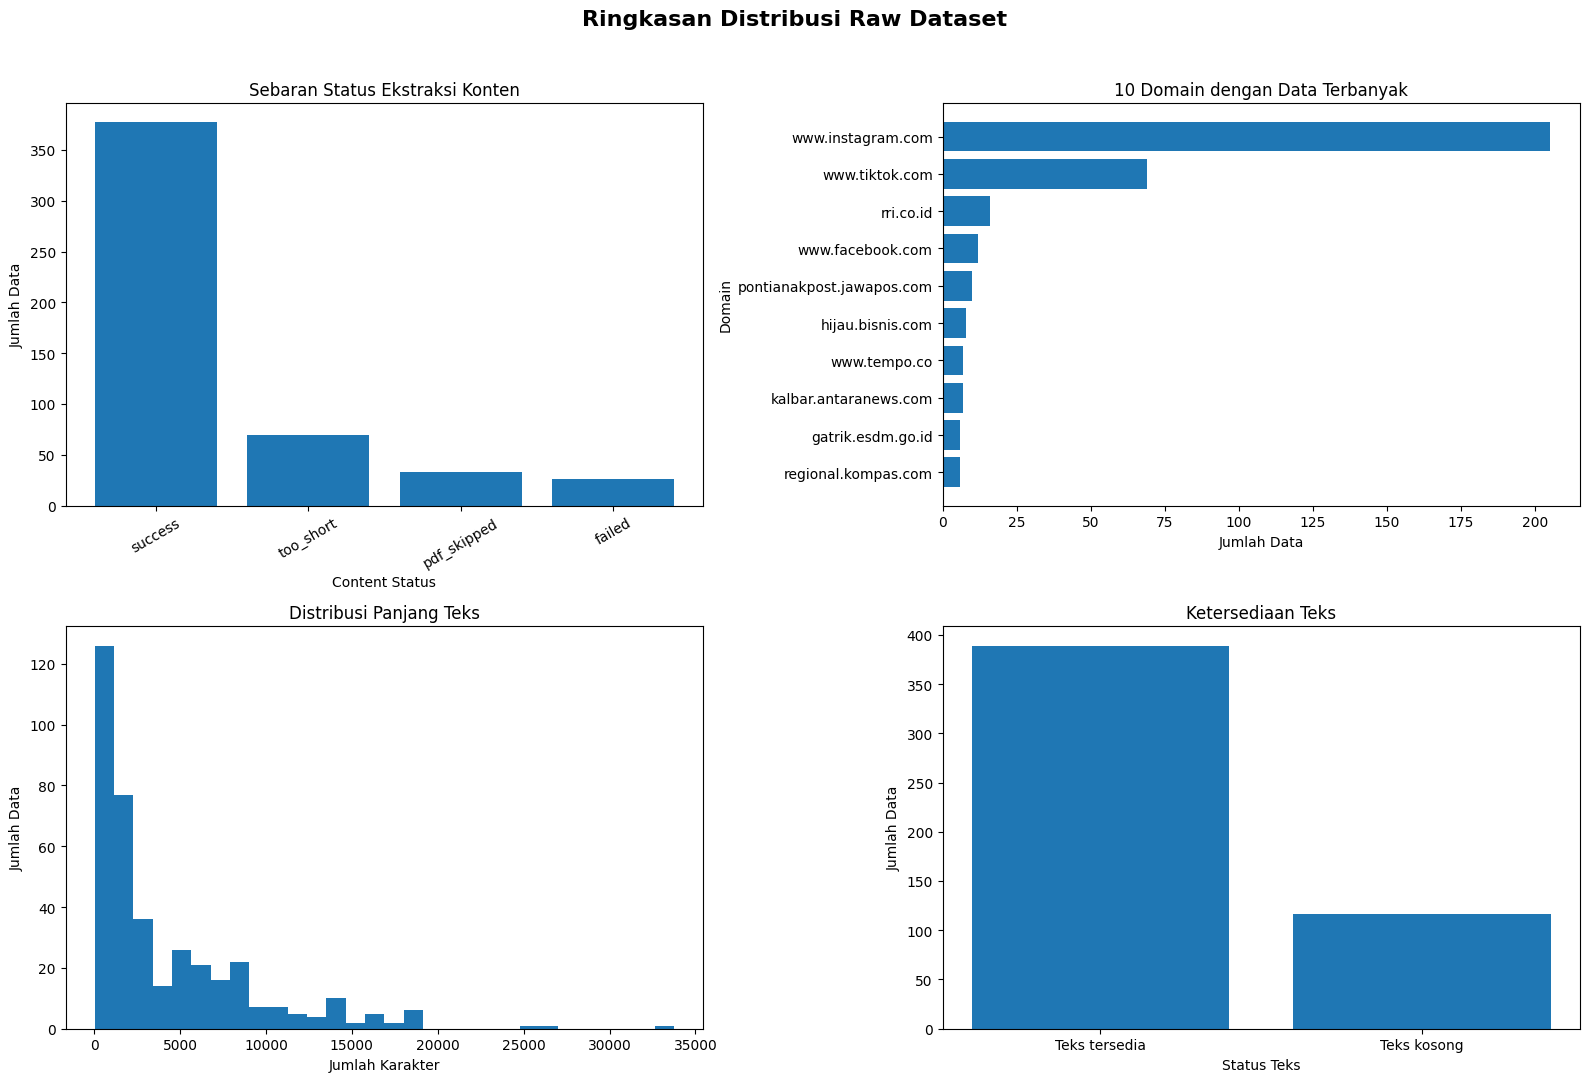

In [12]:
import matplotlib.pyplot as plt

# 1. Sebaran content_status
status_distribution = (
    records_df.with_columns(pl.col("content_status").fill_null("missing"))
    .group_by("content_status")
    .agg(pl.len().alias("jumlah"))
    .sort("jumlah", descending=True)
)


# 2. Sepuluh domain terbanyak
domain_distribution = (
    records_df.with_columns(pl.col("domain").fill_null("unknown"))
    .group_by("domain")
    .agg(pl.len().alias("jumlah"))
    .sort("jumlah", descending=True)
    .head(10)
    .sort("jumlah")
)


# 3. Distribusi panjang teks
text_length_df = records_df.filter(
    pl.col("text").is_not_null() & (pl.col("text").str.len_chars() > 0)
).with_columns(pl.col("text").str.len_chars().alias("text_length"))


# 4. Ketersediaan teks
text_availability = (
    records_df.select(
        pl.when(
            pl.col("text").is_not_null()
            & (pl.col("text").str.strip_chars().str.len_chars() > 0)
        )
        .then(pl.lit("Teks tersedia"))
        .otherwise(pl.lit("Teks kosong"))
        .alias("status_text")
    )
    .group_by("status_text")
    .agg(pl.len().alias("jumlah"))
    .sort("jumlah", descending=True)
)


# Membuat satu figure dengan empat diagram
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 11),
)


# Diagram 1: content status
axes[0, 0].bar(
    status_distribution["content_status"].to_list(),
    status_distribution["jumlah"].to_list(),
)

axes[0, 0].set_title("Sebaran Status Ekstraksi Konten")
axes[0, 0].set_xlabel("Content Status")
axes[0, 0].set_ylabel("Jumlah Data")
axes[0, 0].tick_params(
    axis="x",
    rotation=30,
)


# Diagram 2: domain
axes[0, 1].barh(
    domain_distribution["domain"].to_list(),
    domain_distribution["jumlah"].to_list(),
)

axes[0, 1].set_title("10 Domain dengan Data Terbanyak")
axes[0, 1].set_xlabel("Jumlah Data")
axes[0, 1].set_ylabel("Domain")


# Diagram 3: panjang teks
axes[1, 0].hist(
    text_length_df["text_length"].to_list(),
    bins=30,
)

axes[1, 0].set_title("Distribusi Panjang Teks")
axes[1, 0].set_xlabel("Jumlah Karakter")
axes[1, 0].set_ylabel("Jumlah Data")


# Diagram 4: ketersediaan teks
axes[1, 1].bar(
    text_availability["status_text"].to_list(),
    text_availability["jumlah"].to_list(),
)

axes[1, 1].set_title("Ketersediaan Teks")
axes[1, 1].set_xlabel("Status Teks")
axes[1, 1].set_ylabel("Jumlah Data")


fig.suptitle(
    "Ringkasan Distribusi Raw Dataset",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [13]:
SPESIFIC_FILTER_CONDITION = [
    (pl.col("content_status") == "success"),
]
filtered_df = records_df.filter(f for f in SPESIFIC_FILTER_CONDITION).select(
    COLUMN_SELECTED
)

display(filtered_df)
display(filtered_df["canonical_url"][0])
display(filtered_df["text"][0])

output_path = Path("./outputs/datasets/filtered_records.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

records = filtered_df.to_dicts()

with output_path.open("w", encoding="utf-8") as file:
    json.dump(
        records,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print(f"File disimpan di: {output_path.resolve()}")

canonical_url,domain,title_url,title_content,snippet,content_status,text
str,str,str,str,str,str,str
"""https://www.suarapemredkalbar.…","""www.suarapemredkalbar.com""","""Program Listrik Desa di Papua …","""Program Listrik Desa di Papua …","""suarapemredkalbar.com https://…","""success""","""Sabtu, 27 Juni 2026 Breaking N…"
"""https://www.instagram.com/reel…","""www.instagram.com""","""Bekasi beres. Semangat…!! Antr…","""Ari Yunianto on Instagram: ""Be…","""Instagram · ariyuniant0 2 suka""","""success""","""Log InSign UpNever miss a post…"
"""https://www.instagram.com/reel…","""www.instagram.com""","""OIS POWER | #PLTS #PanelSurya …","""OIS POWER on Instagram: ""#PLTS…","""Instagram · ois_power 6 suka ·…","""success""","""Log InSign UpNever miss a post…"
"""https://www.instagram.com/p/DR…","""www.instagram.com""","""Panel Surya Listrik (Fotovolta…","""TEKNIK LISTRIK on Instagram: ""…","""Instagram · teknik_listrik29 6…","""success""","""Log InSign UpNever miss a post…"
"""https://www.instagram.com/reel…","""www.instagram.com""","""Waktu yg tepat untuk membersih…","""Datascrip Service Center on In…","""Instagram · datascrip.service.…","""success""","""Log InSign UpNever miss a post…"
…,…,…,…,…,…,…
"""https://www.jurnal.bimaberilmu…","""www.jurnal.bimaberilmu.com""","""Pembuatan Alat Peraga Energi T…","""www.jurnal.bimaberilmu.com""","""kos.co.id https://www.jurnal.b…","""success""","""This site can’t be reached www…"
"""https://inspirasikalbar.com/pl…","""inspirasikalbar.com""","""PLN Latih Warga Nanga Nuar Kua…","""PLN Latih Warga Nanga Nuar Kua…","""Inspirasi Kalbar https://inspi…","""success""","""Skip to content Beranda Berita…"
"""https://insidepontianak.com/si…","""insidepontianak.com""","""Berkah Ramadan, 49 Keluarga Pr…","""Berkah Ramadan, 49 Keluarga Pr…","""Inside Pontianak https://insid…","""success""","""Beranda Nasional Berkah Ramada…"


'https://www.suarapemredkalbar.com/read/nasional/26062026/program-listrik-desa-di-papua-hadirkan-terang-dan-harapan-hingga-pelosok-negeri'

'Sabtu, 27 Juni 2026\nBreaking News\nKetika Petani Madura dan Tionghoa Menjaga Pangan Pontianak\nLewat Serangkaian Test, Astra Motor Kalbar Sukses Selenggarakan Technical Skill Contest 2026\nAHM Best Student Ajak Ubah Ide Jadi Inovasi untuk Negeri, Pendaftaran Dibuka untuk Pelajar Terbaik\nHSC Pontianak Sukses Jadi Tuan Rumah Gelar Jamnas FSI XVII untuk Pertama Kali Berkat Dukungan Penuh Astra Motor Kalbar\nHonda Big Bos 2026 Jelajah Tiga Negara Lewati Bumi Khatulistiwa, Astra Motor Kalbar Lepas Peserta Touring Internasional Bertajuk Borneo Journey Vol 2 2026-Across 3 Countries\nDukungan Astra Motor Kalbar Perkuat Pelaksanaan Ujian Kompetensi Keahlian Sekolah Vokasi di SMKS Bahtera Jagoy Babang\nPromo Juni Makin Menawan dari Astra Motor Kalbar Diburu Konsumen Loyal\nAHM Hadirkan Skutik Sporti New Honda Vario Evo 160, Karya Evolusi Terbaru dengan Berbagai Teknologi Terbaik\nUNOSO Gandeng DJKI Kemenkum, Perkuat Budaya Inovasi dan Perlindungan Hak Kekayaan Intelektual\nNasional\nKiwi\n26 

File disimpan di: E:\School\tugas-akhir\project\outputs\datasets\filtered_records.json
